In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
df = pd.read_excel("dataset_cl_completo.xlsx")

In [3]:
X_cols = [
    "distance_to_coast",
    "elevation",
    "merra2_sssmass",
    "era5_wind_speed",
    "era5_time_of_wind",
    "roughness_mean"
]

y_col = "cl"

In [4]:
def stratify_cl(x):

    if x <= 3:
        return "s0"

    elif x <= 60:
        return "s1"

    elif x <= 300:
        return "s2"

    elif x <= 1500:
        return "s3"

    else:
        return "s4"
    
    

In [5]:
df["salinity_class"] = df[y_col].apply(
    stratify_cl
)

In [7]:
train_projects = [
    "international_micat_1998",
    "international_isocorrag_2010",
    "chile_vera_2012",
    "spain_canary_isles_2019",
    "international_cole_2003",
    "brazil_nutec_2008",
    "brazil_sica_2006",
    "brazil_portella_2011",
    "brazil_vitali_2013",
    "brazil_brambilla_2011",
    "brazil_pontes_2011"
]

test_projects = [
    "brazil_portella_2012",
    "brazil_vitali_2013",
    "brazil_brambilla_2011",
    "brazil_pontes_2011"
]

df_train = df[
    df["project_name"].isin(train_projects)
].copy()

df_test = df[
    df["project_name"].isin(test_projects)
].copy()

In [8]:
X_train = df_train[X_cols]
y_train = df_train[y_col]

X_test = df_test[X_cols]
y_test = df_test[y_col]

stratify_train = df_train["salinity_class"]

In [11]:
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=15,
    bootstrap=False,
    random_state=42
)

et = ExtraTreesRegressor(
    n_estimators=400,
    criterion='poisson',
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    bootstrap=False,
    random_state=42
)

svr = Pipeline([
    (
        "scaler",
        MinMaxScaler()
    ),
    (
        "svr",
        SVR(
            kernel='rbf',
            gamma='scale',
            epsilon=0.2,
            C=100
        )
    )
])

In [12]:
models = {
    "RF": rf,
    "ET": et,
    "SVR": svr,
}

In [13]:
cv = StratifiedShuffleSplit(
    n_splits=100,
    train_size=0.8,
    random_state=42
)

In [14]:
def evaluate_model(
        model,
        X,
        y,
        stratify
):

    results = []

    for train_idx, val_idx in cv.split(
            X,
            stratify
    ):

        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)

        results.append({
            "R2":
                r2_score(y_val, pred),

            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        y_val,
                        pred
                    )
                ),

            "MAPE":
                mean_absolute_percentage_error(
                    y_val,
                    pred
                )
        })

    return pd.DataFrame(results)

In [15]:
validation_results = {}

for name, model in models.items():

    validation_results[name] = evaluate_model(
        model,
        X_train,
        y_train,
        stratify_train
    )

In [16]:
summary_validation = pd.DataFrame({
    name: df_.mean()
    for name, df_ in validation_results.items()
}).T

summary_validation

,R2,RMSE,MAPE
RF,0.781578,47.351821,0.790002
ET,0.665775,59.250524,1.800851
SVR,0.167530,95.288648,0.915947


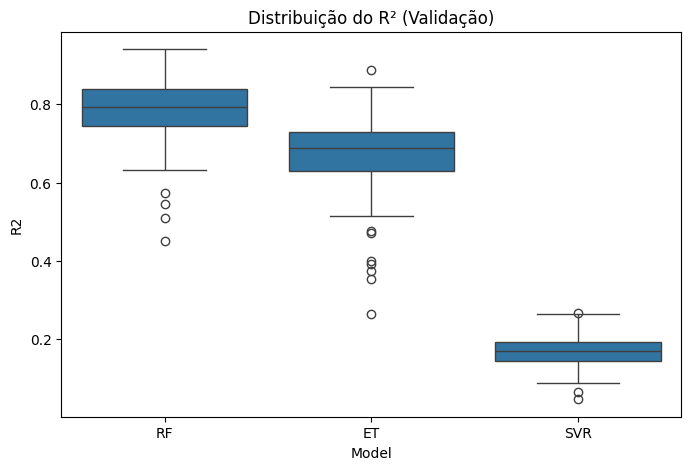

In [17]:
all_results = []

for name, df_result in validation_results.items():

    temp = df_result.copy()

    temp["Model"] = name

    all_results.append(temp)

results = pd.concat(
    all_results,
    ignore_index=True
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title(
    "Distribuição do R² (Validação)"
)

plt.show()

In [18]:
test_results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    test_results.append({

        "Model": name,

        "R2":
            r2_score(
                y_test,
                pred
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            ),

        "MAPE":
            mean_absolute_percentage_error(
                y_test,
                pred
            )
    })

summary_test = pd.DataFrame(
    test_results
)

summary_test

,Model,R2,RMSE,MAPE
0,RF,0.942336,40.764881,0.223018
1,ET,0.254403,146.583854,1.025666
2,SVR,-0.170591,183.669342,0.788526


In [19]:
comparison = (
    summary_validation
    .reset_index()
    .rename(
        columns={"index":"Model"}
    )
    .merge(
        summary_test,
        on="Model",
        suffixes=(
            "_Validation",
            "_Test"
        )
    )
)
comparison

,Model,R2_Validation,RMSE_Validation,MAPE_Validation,R2_Test,RMSE_Test,MAPE_Test
0,RF,0.781578,47.351821,0.790002,0.942336,40.764881,0.223018
1,ET,0.665775,59.250524,1.800851,0.254403,146.583854,1.025666
2,SVR,0.167530,95.288648,0.915947,-0.170591,183.669342,0.788526


In [20]:
best_model = models["RF"]

X_full = df[X_cols]
y_full = df[y_col]

best_model.fit(
    X_full,
    y_full
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None the

In [21]:
joblib.dump(
    best_model,
    "modelo_cl.pkl"
)

['modelo_cl.pkl']